# Notebook 1 EDA + Feature Extraction (raw IEMOCAP) backbone HuBERT

Pipeline:

1. **Parsing** with discard counter
2. **EDA** duration cutoff estimated on the train set only; EDA features computed with the same transformations as the extraction
3. **Extraction** 12 mean-pooled SSL layers, temporal chunk embeddings for the attention, extended acoustic/prosodic features, atomic saves



## 1 · Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers librosa soundfile praat-parselmouth -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 97.8 MB/s eta 0:00:00


In [ ]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
import torch
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

PROJ = Path('/content/drive/MyDrive/Colab Notebooks/XAI_SER/code')
sys.path.append(str(PROJ))
import xai_common as xc

BACKBONE     = 'hubert'
PATHS        = xc.get_paths(BACKBONE, PROJ)
OUT_DIR      = PATHS['data']
IEMOCAP_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/XAI_SER/data/IEMOCAP_full_release')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
xc.set_seed()
print(f'Backbone: {BACKBONE} ({xc.MODEL_NAMES[BACKBONE]})   Device: {DEVICE}')
print(f'Sessions found: {sorted(d.name for d in IEMOCAP_ROOT.glob("Session*"))}')

Backbone: hubert (facebook/hubert-base-ls960)   Device: cuda
Sessions found: ['Session1', 'Session2', 'Session3', 'Session4', 'Session5']


## 2 · Parsing with discard counter

filtering 4 classes, exc→hap, fru/fea/sur/dis/oth/xxx discarded, every discarded utterance is counted along with the reason

In [ ]:
# Parse the IEMOCAP EmoEvaluation annotation files, session by session.
# For each session, xc.parse_evaluation_dir() returns:
#   recs  -> list of kept utterance records (utt_id, session, speaker, gender, emotion, emotion_id, session, valence, activation,dominance, wav_path)
#   disc  -> Counter of utterances discarded, keyed by reason (e.g. emotion label not in the 4-class set)
all_records, all_discards = [], Counter()
for session_dir in sorted(IEMOCAP_ROOT.glob('Session*')):
    recs, disc = xc.parse_evaluation_dir(session_dir)
    all_records.extend(recs)
    all_discards.update(disc)
    print(f'  {session_dir.name}: {len(recs)} kept, {sum(disc.values())} discarded')

print()
xc.print_discards(all_discards, len(all_records))
xc.atomic_json(OUT_DIR / 'discard_counter.json', dict(all_discards))

print('\nEmotion distribution:', dict(Counter(r['emotion'] for r in all_records)))
print('Session distribution:', dict(Counter(r['session'] for r in all_records)))

  Session1: 1085 kept, 734 discarded
  Session2: 1023 kept, 788 discarded
  Session3: 1151 kept, 985 discarded
  Session4: 1031 kept, 1072 discarded
  Session5: 1241 kept, 929 discarded

Utterances kept: 5531   discarded: 4508
  emo:xxx                 2507
  emo:fru                 1849
  emo:sur                  107
  emo:fea                   40
  emo:oth                    3
  emo:dis                    2

Emotion distribution: {'neu': 1708, 'ang': 1103, 'sad': 1084, 'hap': 1636}
Session distribution: {'1': 1085, '2': 1023, '3': 1151, '4': 1031, '5': 1241}


## 3 · EDA

### 3a · Classes and sessions' samples distribution

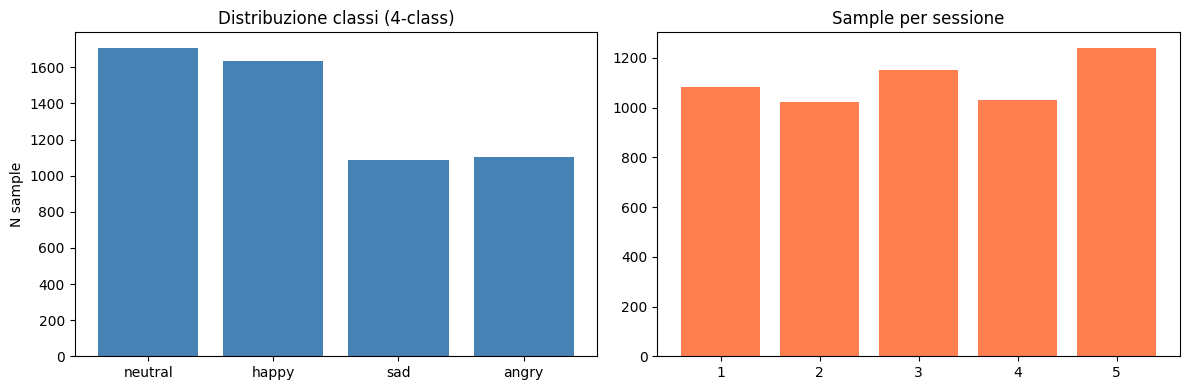

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = Counter(r['emotion'] for r in all_records)
axes[0].bar(xc.LABEL_NAMES, [counts[e] for e in ['neu', 'hap', 'sad', 'ang']], color='steelblue')
axes[0].set_title('Class Distribution (4 Classes) ')
axes[0].set_ylabel('N sample')
sess_c = Counter(r['session'] for r in all_records)
axes[1].bar(sorted(sess_c), [sess_c[s] for s in sorted(sess_c)], color='coral')
axes[1].set_title('Samples per Session')
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_class_session.png', dpi=150); plt.show()

### 3b · Durations → cutoff based on the training set
Normalization of the dataset to reduce dominance of longer audios

Computation of audio durations...


  0%|          | 0/5531 [00:00<?, ?it/s]

p90=8.62s  p95=10.89s  p99=15.31s   (solo train)
Cutoff: 11.0s  (covers the 94.9% of all samples)


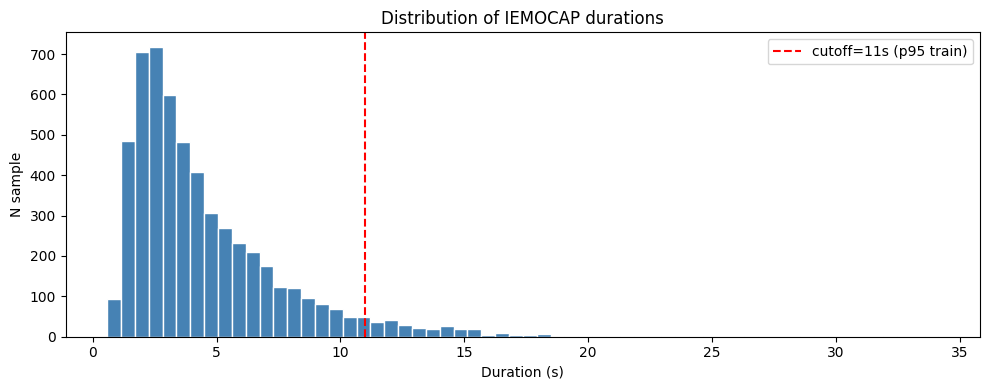

In [ ]:
print('Computation of audio durations...')
durations = np.array([sf.info(r['wav_path']).duration for r in tqdm(all_records)])
is_train  = np.array([r['session'] != '5' for r in all_records])


p90, p95, p99 = np.percentile(durations[is_train], [90, 95, 99])
DURATION_CUTOFF = float(np.ceil(p95))
print(f'p90={p90:.2f}s  p95={p95:.2f}s  p99={p99:.2f}s   (solo train)')
print(f'Cutoff: {DURATION_CUTOFF}s  (covers the {(durations <= DURATION_CUTOFF).mean()*100:.1f}% of all samples)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(durations, bins=60, color='steelblue', edgecolor='white')
ax.axvline(DURATION_CUTOFF, color='red', linestyle='--', label=f'cutoff={DURATION_CUTOFF:.0f}s (p95 train)')
ax.set_xlabel('Duration (s)'); ax.set_ylabel('N sample'); ax.legend()
ax.set_title('Distribution of IEMOCAP durations')
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_durations.png', dpi=150); plt.show()

###3c · Dimensional annotations per emotion - used to visualize how the three continuous dimensions of the dataset (valence, activation, and dominance) are distributed within the four emotion classes (neu, hap, sad, ang)

IEMOCAP is a dataset of audio from acted dialogues in which every speech segment (utterance) has two types of labels.

The first type is the "discrete" label, i.e. the actual emotion class used in our model: neutral, happy, sad, and angry. This is the label the model has to predict.

The second type is a "dimensional" representation of emotion, i.e. three continuous values from 1 to 5: valence, activation, and dominance. Valence indicates how positive or negative the emotion is, activation indicates how intense or energetic it is, and dominance indicates how much in control or dominant the person appears in the situation. These values aren't used as the main target in the task, but they come from human ratings and describe the same emotion in a more continuous, psychological way.


/tmp/ipykernel_824/1602264711.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=xc.LABEL_NAMES, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
/tmp/ipykernel_824/1602264711.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=xc.LABEL_NAMES, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
/tmp/ipykernel_824/1602264711.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=xc.LABEL_NAMES, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))


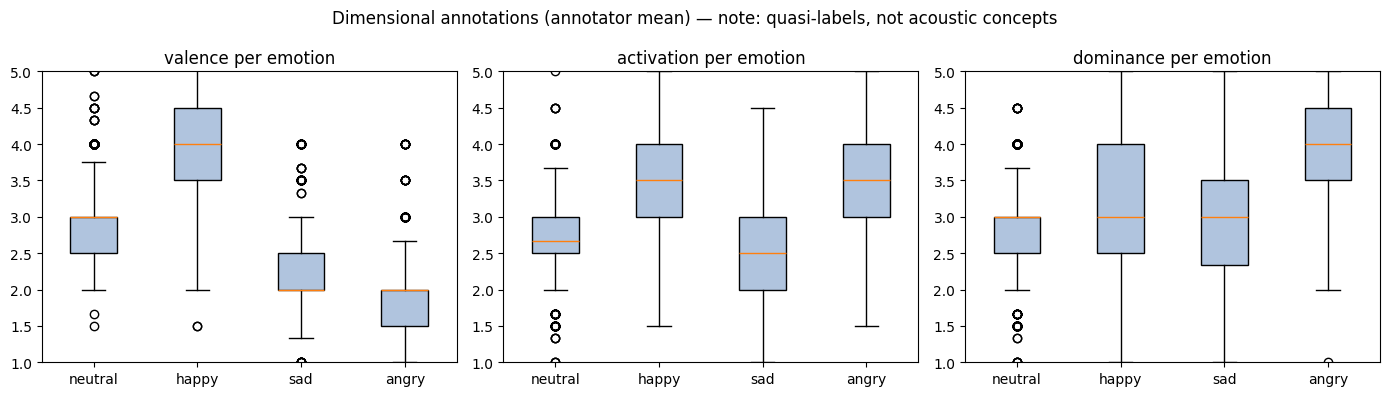

In [ ]:
df = pd.DataFrame(all_records)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, dim in zip(axes, ['valence', 'activation', 'dominance']):
    data = [df[df['emotion'] == e][dim].dropna().values for e in ['neu', 'hap', 'sad', 'ang']]
    ax.boxplot(data, labels=xc.LABEL_NAMES, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(f'{dim} per emotion'); ax.set_ylim(1, 5)
plt.suptitle('Dimensional annotations (annotator mean) - note: quasi-labels, not acoustic concepts')
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_dimensional.png', dpi=150); plt.show()

### 3d · Acoustic features (i.e. numbers describing properties of the audio signal without looking at the linguistic content)

First,  select a random subset of about 300 utterances from the dataset.

Then, for each one, load the audio and truncate it using the same cutoff defined earlier (the one based on the 95th percentile of the train set). This matters because it guarantees that the features we compute in EDA are comparable to the ones we'll use in the final pipeline, avoiding inconsistencies between analysis and training.

At this point we extract the acoustic features with our compute_acoustic function, which includes prosodic and voice-quality information such as energy (RMS), jitter, shimmer, harmonicity (HNR), speech rate, and pause ratio, plus a few MFCC features. These features are then paired with the emotion label of each sample.

The goal is to see whether coherent patterns emerge: for instance, higher energy and speech rate in activated emotions like anger or happiness, or higher pause ratio and lower energy in emotions like sadness.


EDA acoustic:   0%|          | 0/300 [00:00<?, ?it/s]

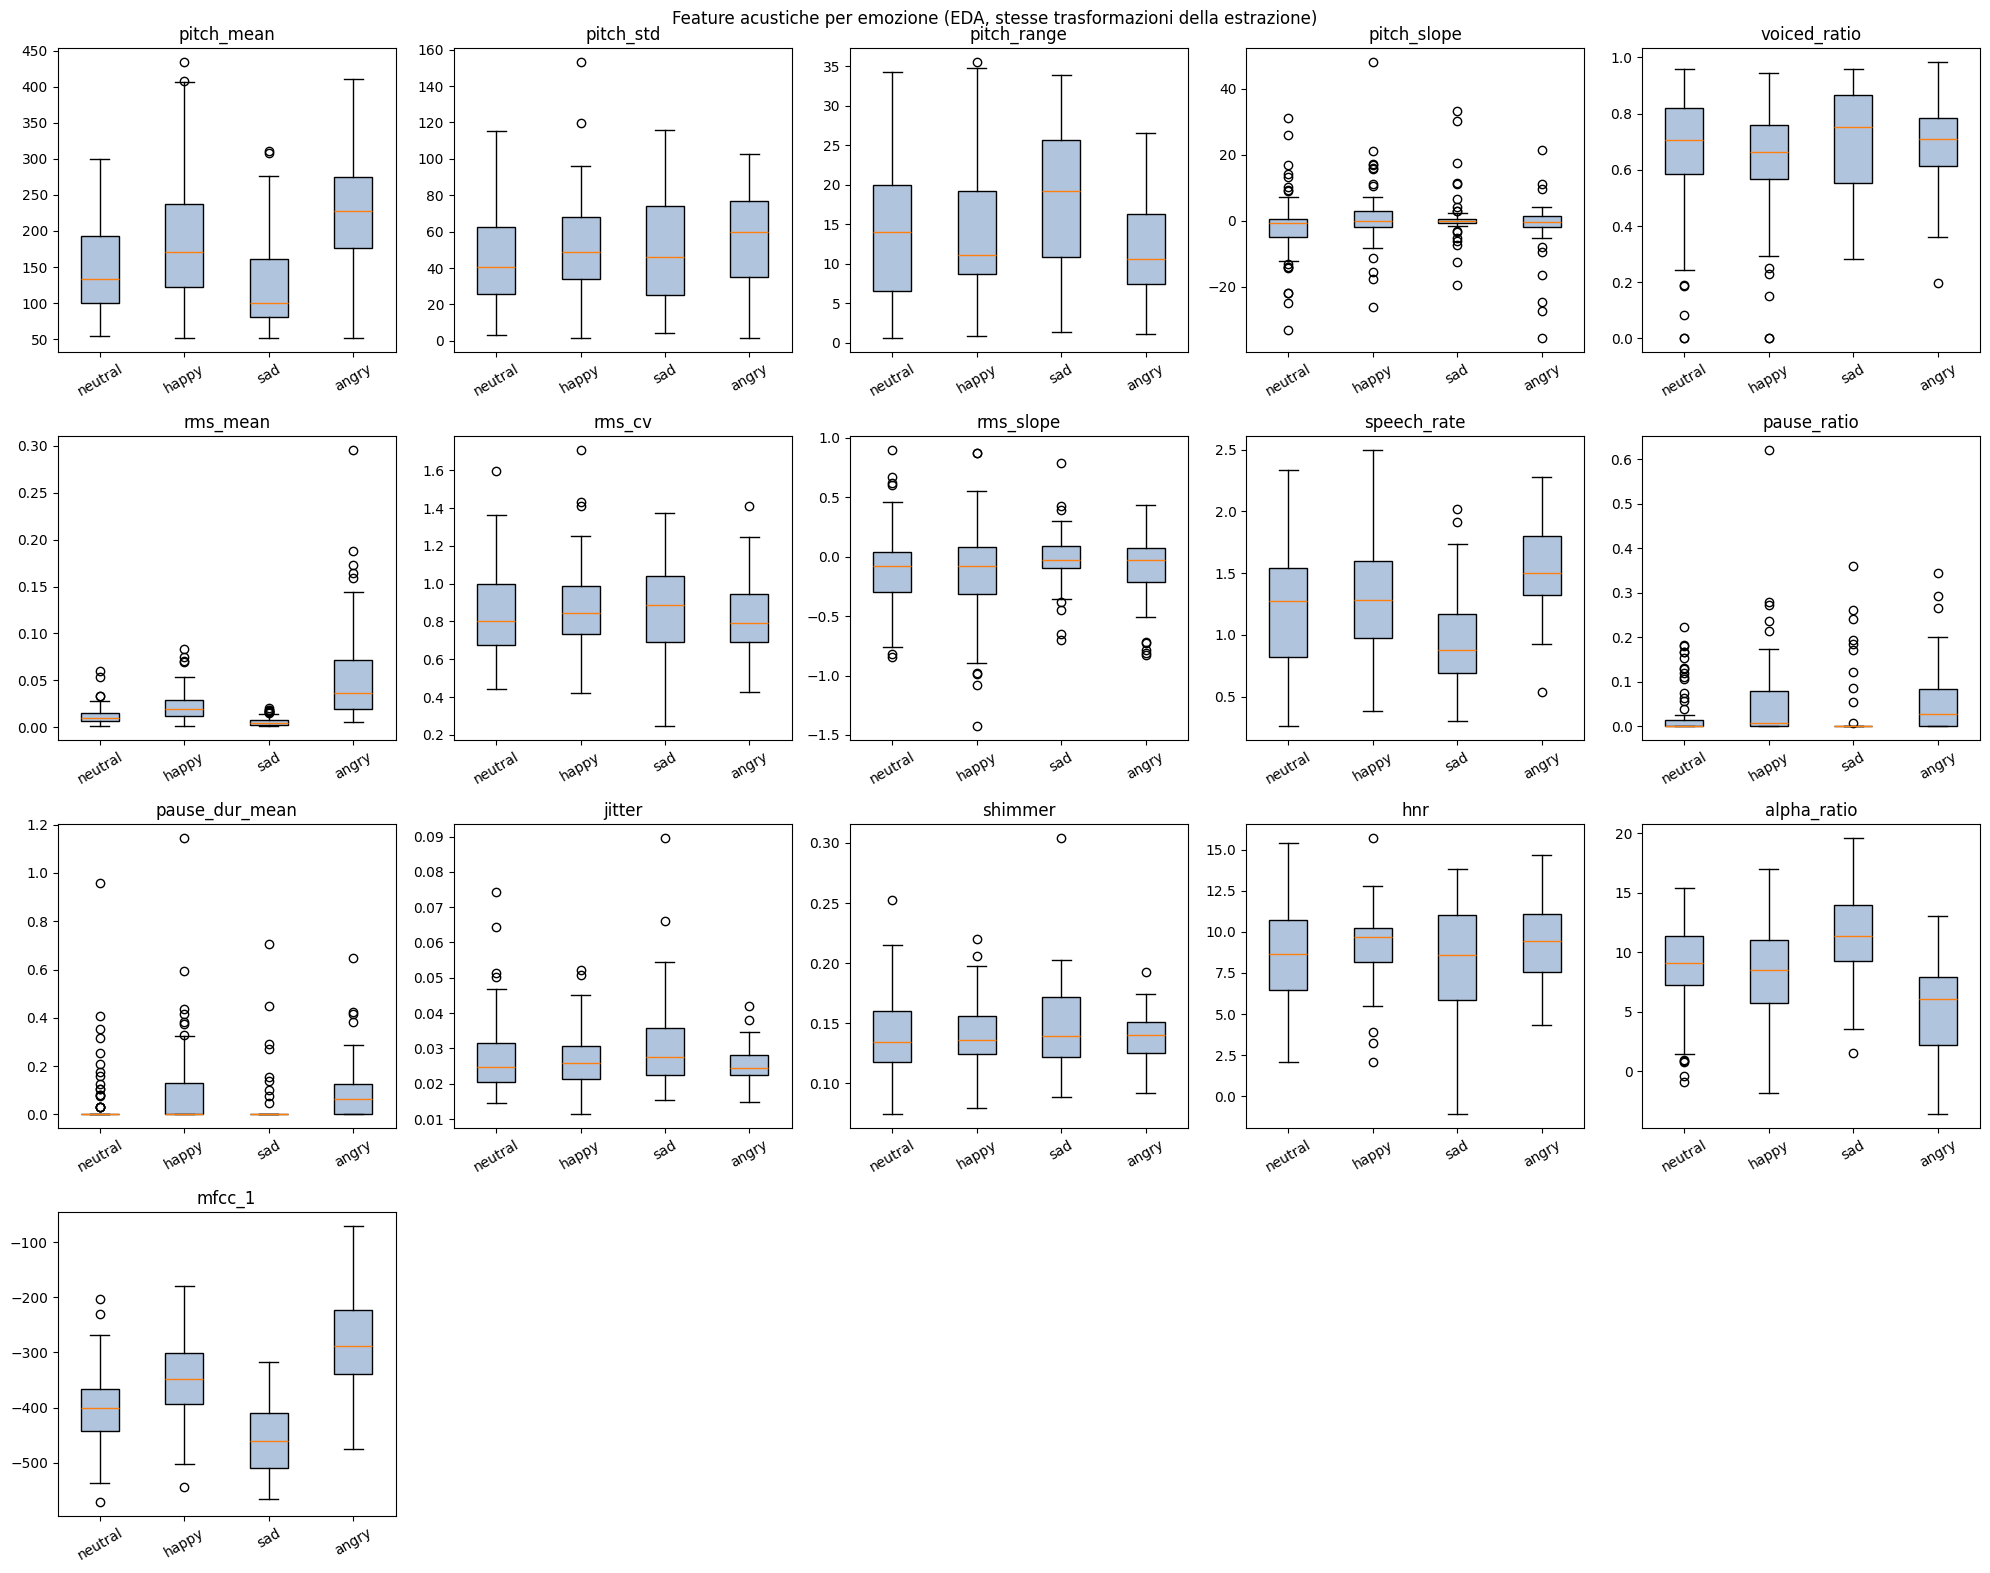

In [ ]:
def load_and_truncate(wav_path, sr=16000):
    audio, _ = librosa.load(wav_path, sr=sr, mono=True)
    return audio[:int(DURATION_CUTOFF * sr)]

np.random.seed(xc.SEED)
eda_records = [all_records[i] for i in np.random.choice(len(all_records), 300, replace=False)]
eda_feats = []
for r in tqdm(eda_records, desc='EDA acoustic'):
    f = xc.compute_acoustic(load_and_truncate(r['wav_path']))
    f['emotion'] = r['emotion']
    eda_feats.append(f)
df_eda = pd.DataFrame(eda_feats)

eda_cols = xc.ACOUSTIC_CONCEPTS + ['mfcc_1']
n_rows = int(np.ceil(len(eda_cols) / 5))
fig, axes = plt.subplots(n_rows, 5, figsize=(20, 4 * n_rows))
for ax in axes.flat[len(eda_cols):]:
    ax.axis('off')
for ax, feat in zip(axes.flat, eda_cols):
    data = [df_eda[df_eda['emotion'] == e][feat].dropna().values for e in ['neu', 'hap', 'sad', 'ang']]
    ax.boxplot(data, tick_labels=xc.LABEL_NAMES, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(feat); ax.tick_params(axis='x', rotation=30)
plt.suptitle('Feature acustiche per emozione (EDA, stesse trasformazioni della estrazione)')
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_acoustic_boxplot.png', dpi=150); plt.show()

### 3e · Correlation between features (redundancy check)

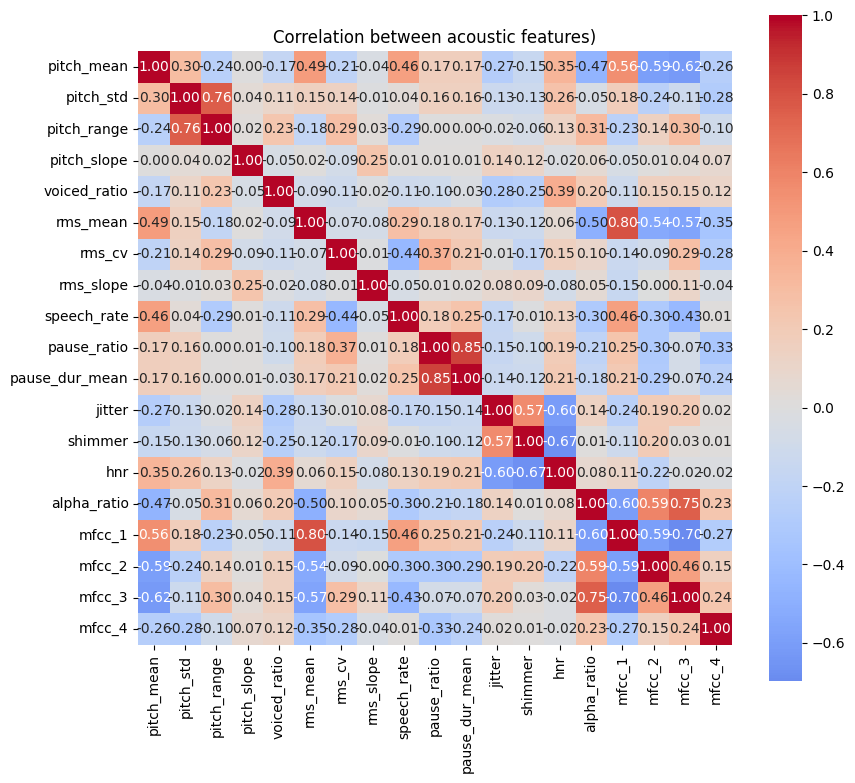

In [ ]:
cols = xc.ACOUSTIC_CONCEPTS + xc.MFCC_CONCEPTS
corr = df_eda[cols].corr()
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation between acoustic features)')
plt.tight_layout(); plt.savefig(OUT_DIR / 'eda_concept_corr.png', dpi=150); plt.show()

## 4 · Load the SSL backbone (frozen)

In [ ]:
from transformers import AutoFeatureExtractor, HubertModel, Wav2Vec2Model

MODEL_NAME = xc.MODEL_NAMES[BACKBONE]
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
ModelCls = HubertModel if BACKBONE == 'hubert' else Wav2Vec2Model
model = ModelCls.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
for p in model.parameters():
    p.requires_grad = False
print(f'{MODEL_NAME} loaded and frozen (12 layer transformer)')

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

facebook/hubert-base-ls960 loaded and frozen (12 layer transformer)


## 5 · Extraction
We turn every audio clip into numerical representations that we'll use for the rest of the project.

First we extract the acoustic features with compute_acoustic - all the information like energy, jitter, shimmer, speech rate, pause ratio, etc. This gets saved as a dictionary for each id.

Then we pass the audio to the HuBERT model (already loaded in point 4) and get the model's internal representations. Here we save two types: a "global per-layer" representation, i.e. the mean over time for each of the 12 layers (so one vector per layer), and a "temporal" representation, i.e. we split the frame sequence into 8 chunks and average each chunk. This is needed because we don't just want a static representation of the whole audio, but also a temporal structure useful for any future attention models or dynamic analyses.

Finally we save everything to disk together with a checkpoint of the utterances already processed, so we can interrupt and resume without redoing everything.
For each utterance we save:

- `layer_embeddings.npz` → (12, 768) mean-pooled per layer (SSL input with edge silences trimmed)
- `chunk_embeddings.npz` → (8, 768) averaged over the 12 layers for 8 temporal segments (for temporal attention)
- `acoustic_features.json` → acoustic/prosodic features (full audio: internal pauses are needed for pause_ratio)


In [ ]:
CHECKPOINT    = OUT_DIR / 'checkpoint.json'
LAYERS_FILE   = OUT_DIR / 'layer_embeddings.npz'
CHUNKS_FILE   = OUT_DIR / 'chunk_embeddings.npz'
ACOUSTIC_FILE = OUT_DIR / 'acoustic_features_v3.json'

done       = set(json.load(open(CHECKPOINT))) if CHECKPOINT.exists() else set()
layer_embs = dict(np.load(LAYERS_FILE, allow_pickle=True)) if LAYERS_FILE.exists() else {}
chunk_embs = dict(np.load(CHUNKS_FILE, allow_pickle=True)) if CHUNKS_FILE.exists() else {}
acoustic   = json.load(open(ACOUSTIC_FILE)) if ACOUSTIC_FILE.exists() else {}
todo = [r for r in all_records if r['utt_id'] not in done]
print(f'Checkpoint: {len(done)} already extracted, still to process: {len(todo)}')

Checkpoint: 5531 already extracted, still to process: 0


In [ ]:
SAVE_EVERY = 100

def save_all():
    #atomic: write to a temp file + rename, never corrupted/misaligned artifacts
    xc.atomic_savez(LAYERS_FILE, **layer_embs)
    xc.atomic_savez(CHUNKS_FILE, **chunk_embs)
    xc.atomic_json(ACOUSTIC_FILE, acoustic)
    xc.atomic_json(CHECKPOINT, sorted(done))

for i, record in enumerate(tqdm(todo)):
    uid = record['utt_id']
    try:
        audio, sr = librosa.load(record['wav_path'], sr=16000, mono=True)
    except Exception as e:
        print(f'  Skip {uid}: {e}')
        continue
    audio = audio[:int(DURATION_CUTOFF * sr)]     # cutoff based on training

    # Acoustic features: edge trimming happens inside compute_acoustic,
    # so pause_ratio only measures internal (communicative) pauses, not
    # recording silence - consistent with the SSL input, already trimmed
    acoustic[uid] = xc.compute_acoustic(audio, sr)

    # SSL trimmed Input
    audio_ssl = xc.trim_edges(audio)
    inputs = feature_extractor(audio_ssl, sampling_rate=sr, return_tensors='pt')
    with torch.no_grad():
        out = model(inputs.input_values.to(DEVICE), output_hidden_states=True)
        hs = torch.stack(out.hidden_states[1:], dim=0).squeeze(1)          # (12, T, 768)
        layer_embs[uid] = hs.mean(dim=1).cpu().numpy().astype(np.float32)  # (12, 768)
        # Temporal chuncks: T frame -> 8 segments, mean on layers
        frames = hs.mean(dim=0).cpu().numpy()                              # (T, 768)
        splits = np.array_split(np.arange(frames.shape[0]), xc.N_CHUNKS)
        chunks = [frames[s].mean(axis=0) if len(s) else frames.mean(axis=0) for s in splits]
        chunk_embs[uid] = np.stack(chunks).astype(np.float16)              # (8, 768)

    done.add(uid)
    if (i + 1) % SAVE_EVERY == 0:
        save_all()

save_all()
# v2 migration: if the embeddings already exist (checkpoint) but the v2
# acoustic features don't, recompute ONLY the features (CPU, no SSL
# re-extraction: the trimming for the backbone input was already there, the embeddings don't change).
todo_ac = [r for r in all_records if r['utt_id'] in done and r['utt_id'] not in acoustic]
for i, record in enumerate(tqdm(todo_ac, desc='acoustic v2')):
    try:
        audio, sr = librosa.load(record['wav_path'], sr=16000, mono=True)
    except Exception as e:
        print(f"  Skip {record['utt_id']}: {e}")
        continue
    acoustic[record['utt_id']] = xc.compute_acoustic(audio[:int(DURATION_CUTOFF * sr)], sr)
    if (i + 1) % SAVE_EVERY == 0:
        xc.atomic_json(ACOUSTIC_FILE, acoustic)
xc.atomic_json(ACOUSTIC_FILE, acoustic)

print(f'Extracted: {len(layer_embs)}   layer: {next(iter(layer_embs.values())).shape}'
      f'   chunk: {next(iter(chunk_embs.values())).shape}   acoustic v2: {len(acoustic)}')

0it [00:00, ?it/s]

acoustic v2: 0it [00:00, ?it/s]

Extracted: 5531   layer: (12, 768)   chunk: (8, 768)   acoustic v2: 5531


##6 · Save metadata, concepts, and labels
Builds the final structured dataset (feature matrix + labels + metadata), saves it in a reusable format, and checks data quality.

`X_concepts` contains three levels: acoustic/prosodic (deployable), MFCC (ablation only), dimensional V/A/D (quasi-labels: human annotations of the same emotion - never used in the XAI evaluation). NaNs are left as NaN: they'll be imputed in NB2 using train medians.


In [ ]:
valid_ids = [r['utt_id'] for r in all_records if r['utt_id'] in layer_embs]
rec_by_id = {r['utt_id']: r for r in all_records}

def _num(v):
    # standard JSON files don't have NaN: atomic_jason serialize them as null
    return float(v) if v is not None else float('nan')

metadata, X_rows, y_rows = {}, [], []
for uid in valid_ids:
    r, af = rec_by_id[uid], acoustic[uid]
    if 'rms_cv' not in af:
        _m, _s = af.get('rms_mean'), af.get('rms_std')
        af['rms_cv'] = (_s / _m) if (_m is not None and _s is not None and _m > 0) else float('nan')
    metadata[uid] = {k: r[k] for k in ['emotion', 'emotion_id', 'session', 'speaker',
                                       'gender', 'valence', 'activation', 'dominance']}
    X_rows.append([_num(af.get(c)) for c in xc.ACOUSTIC_CONCEPTS + xc.MFCC_CONCEPTS]
                  + [_num(r['valence']), _num(r['activation']), _num(r['dominance'])])
    y_rows.append(r['emotion_id'])

X_concepts = np.array(X_rows, dtype=np.float32)
y_emotion  = np.array(y_rows, dtype=np.int64)

np.save(OUT_DIR / 'X_concepts.npy', X_concepts)
np.save(OUT_DIR / 'y_emotion.npy', y_emotion)
xc.atomic_json(OUT_DIR / 'valid_ids.json', valid_ids)
xc.atomic_json(OUT_DIR / 'metadata.json', metadata)
xc.atomic_json(OUT_DIR / 'concept_names.json', xc.ALL_CONCEPTS)

nan_frac = np.isnan(X_concepts).mean(axis=0)
print(f'Valid samples: {len(valid_ids)}   X_concepts: {X_concepts.shape}')
print('Nan fraction per concept:')
for c, f in zip(xc.ALL_CONCEPTS, nan_frac):
    print(f'  {c:12s} {f:.3f}')
print('Distribution:', dict(Counter(y_emotion.tolist())))
print(f'Everything saved in {OUT_DIR}')

Valid samples: 5531   X_concepts: (5531, 22)
Nan fraction per concept:
  pitch_mean   0.011
  pitch_std    0.011
  pitch_range  0.011
  pitch_slope  0.011
  voiced_ratio 0.000
  rms_mean     0.000
  rms_cv       0.000
  rms_slope    0.000
  speech_rate  0.000
  pause_ratio  0.000
  pause_dur_mean 0.000
  jitter       0.003
  shimmer      0.003
  hnr          0.000
  alpha_ratio  0.000
  mfcc_1       0.000
  mfcc_2       0.000
  mfcc_3       0.000
  mfcc_4       0.000
  valence      0.000
  activation   0.000
  dominance    0.000
Distribution: {0: 1708, 3: 1103, 2: 1084, 1: 1636}
Everything saved in /content/drive/MyDrive/Colab Notebooks/XAI_SER/code/my_outputs_Hubert
